# InceptionV3: Interpreting the model
## Loading python modules

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms,datasets
from torchvision.models import Inception_V3_Weights
from PIL import Image
from torch.utils.data import DataLoader
import prettypyplot as pplt
import seaborn as sns
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import torch.nn.functional as F
import cv2
import pandas as pd

## Loading datasets

In [ ]:
transform=transforms.Compose([transforms.Resize((299,299)),transforms.ToTensor()])
dataset_train=datasets.ImageFolder(root='../../train_oversampling',transform=transform)
class_names=dataset_train.classes
dataset_test=datasets.ImageFolder(root='../../test',transform=transform)
dataset_val=datasets.ImageFolder(root='../../val',transform=transform)
dataloader_train=DataLoader(dataset_train,batch_size=32,shuffle=True)
dataloader_test=DataLoader(dataset_test,batch_size=32,shuffle=True)
dataloader_val=DataLoader(dataset_val,batch_size=32,shuffle=True)
class_names=['BAS','EOS','EBO','IG','LYT','MON','NGS','PLA']

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


## Loading the model

In [3]:
model = torch.load('inceptionv3.pth',weights_only=False,map_location=torch.device('cpu'))
if isinstance(model, torch.nn.DataParallel):
    model = model.module


## Load the weights and define the preprocess and the loss functions

In [ ]:
weights = Inception_V3_Weights.DEFAULT
device = 'cpu'
preprocess = weights.transforms()
criterion=nn.CrossEntropyLoss()

## plot the loss and accuracy curves

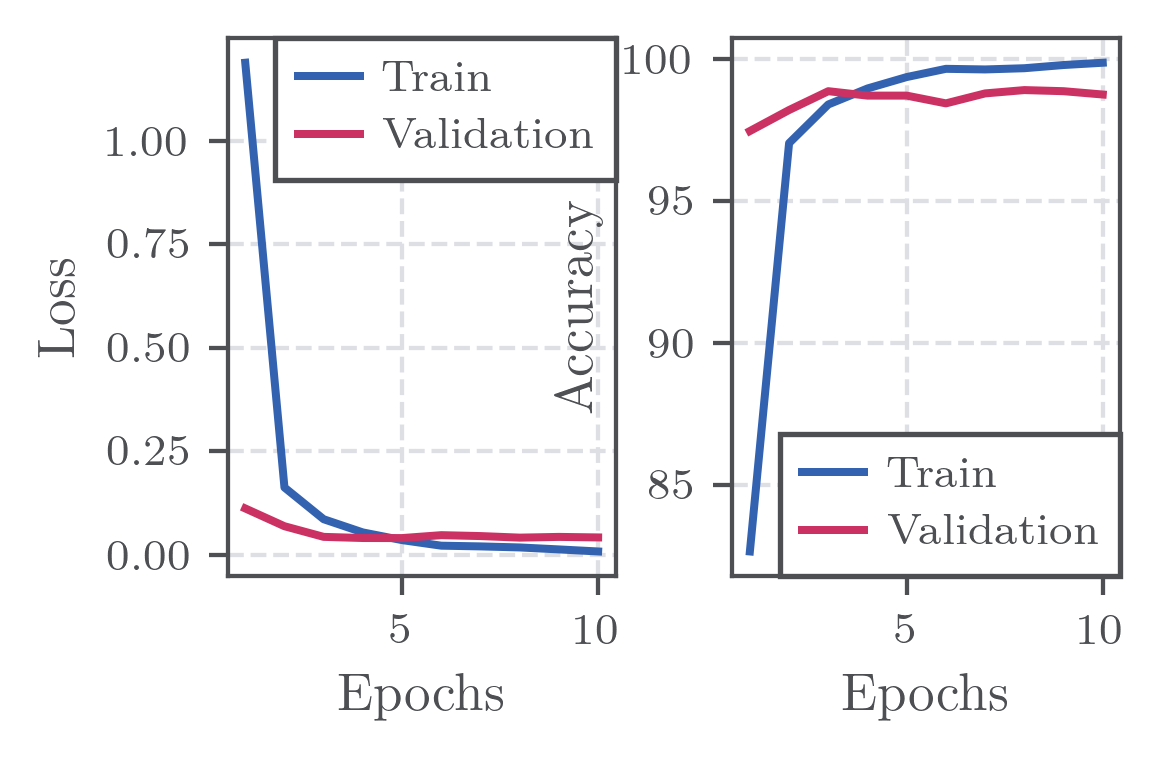

In [15]:
pplt.use_style()
data=np.loadtxt('./history_inceptionv3.txt')
train_loss,train_acc,validation_loss,validation_acc=data[:,0],data[:,1],data[:,2],data[:,3]
fig,ax=plt.subplots(1,2,figsize=(3,2),gridspec_kw={'wspace':0.3})
# plt.subplot(121)
ax[0].plot(np.arange(len(train_loss))+1,train_loss,label='Train')
ax[0].plot(np.arange(len(validation_loss))+1,validation_loss,label='Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend();
#plt.subplot(122)
ax[1].plot(np.arange(len(train_acc))+1,train_acc,label='Train')
ax[1].plot(np.arange(len(validation_acc))+1,validation_acc,label='Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
pplt.savefig('loss_acc.png',dpi=300);

## Evaluate the model on the test dataset

In [5]:
def evaluate(dataloader, model, criterion, device):
    model.eval()
    loss_val_total = 0
    predictions, true_vals = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = preprocess(X_batch).to(device), y_batch.to(device)

            outputs = model(X_batch.to(torch.float32))

            if hasattr(outputs, "logits"):  # Inception case
                loss = criterion(outputs.logits, y_batch)
                y_pred = outputs.logits
            else:
                loss = criterion(outputs, y_batch)
                y_pred = outputs

            loss_val_total += loss.item()
            predictions.extend(y_pred.detach().cpu().numpy())
            true_vals.extend(y_batch.cpu().numpy())

    loss_val_avg = loss_val_total / len(dataloader)
    predictions = np.argmax(np.array(predictions), axis=-1)
    true_vals = np.array(true_vals)

    acc = accuracy_score(true_vals, predictions)
    return loss_val_avg, acc, true_vals, predictions


# --- Run on test set ---
test_loss, test_acc, y_true, y_pred = evaluate(dataloader_test, model, criterion, device)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Test Loss: 0.0442 | Test Accuracy: 98.68%

              precision    recall  f1-score   support

         BAS       0.99      1.00      1.00       183
         EOS       1.00      1.00      1.00       468
         EBO       0.99      0.99      0.99       233
          IG       0.98      0.97      0.97       435
         LYT       0.97      1.00      0.99       183
         MON       0.98      0.97      0.97       214
         NGS       0.98      0.98      0.98       500
         PLA       1.00      1.00      1.00       353

    accuracy                           0.99      2569
   macro avg       0.99      0.99      0.99      2569
weighted avg       0.99      0.99      0.99      2569



## calculate and plot the confusion matrix

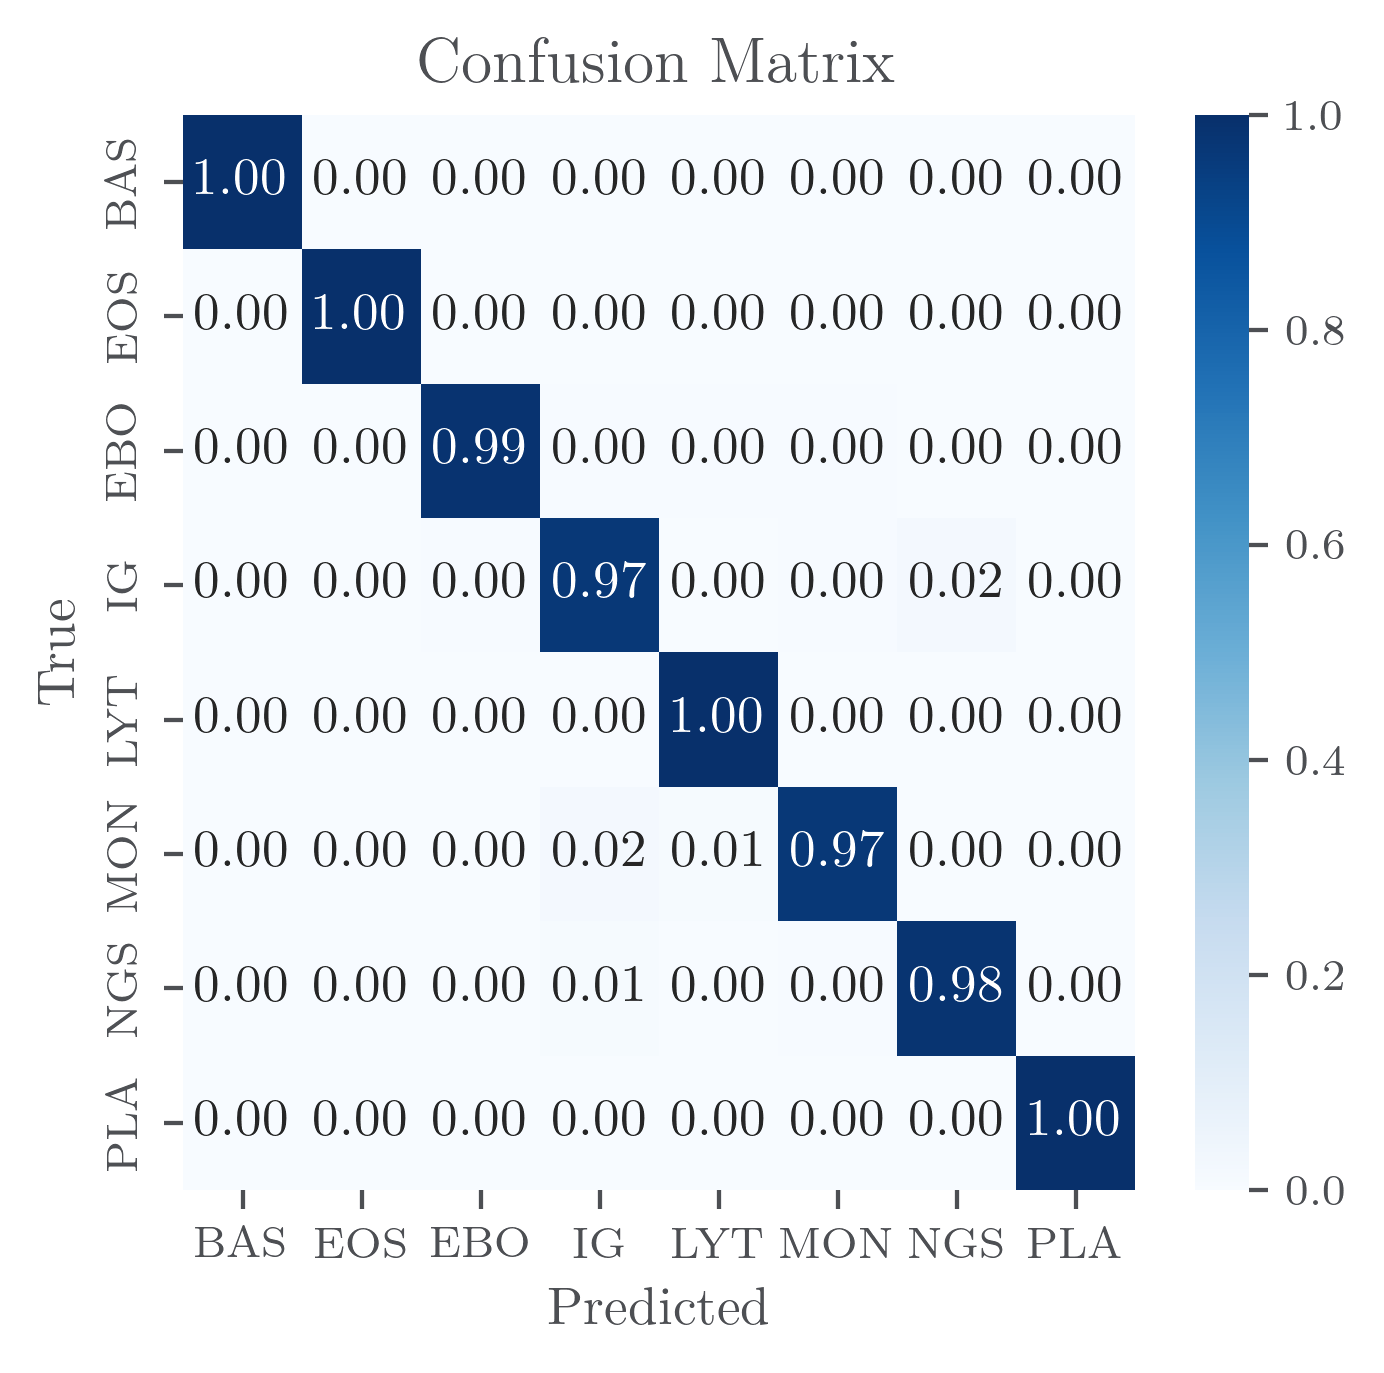

In [6]:
pplt.use_style()
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
#plt.xticks(rotation=45)
plt.title('Confusion Matrix')
#pplt.savefig('cm.png',dpi=300)
plt.show()

## Define a function to get only the edges of a certain image

In [12]:
def get_canny_edge(img, threshold1=30, threshold2=80):
    """
    Function to get the canny edge of an image
    Input: img in (H, W, 3), dtype uint8 or float [0,1]
    Output: edge map (H, W, 3), float in [0,1]
    """
    # If float [0,1], convert to uint8
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)

    # Gray scale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Gaussian blur
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Get the edge (invert edges so white = edge)
    edge = 255 - cv2.Canny(gray, threshold1, threshold2)

    # Convert to 3-channel float [0,1]
    edge = np.stack([edge]*3, axis=-1) / 255.0
    return edge


## Define the Grad-CAM function to interpret the model

In [13]:
def make_gradcam_heatmap(img_tensor, model, target_layer_name, pred_index=None):   
    # Skip forward to get target layer predictions and activations
    def forward_hook(module, input, output):
        model.features = output

    # Register a hook on the target layer to retrieve its outputs
    hook = model._modules.get(target_layer_name).register_forward_hook(forward_hook)
    
    # Perform a forward pass to obtain model outputs
    output = model(img_tensor)
    
    # Remove hook after getting activations
    hook.remove()

    # If no prediction index is provided, use the one with the highest probability
    if pred_index is None:
        pred_index = output.argmax(dim=1).item()
    
    # Class probability value
    y = output[0, pred_index]
    
    # Skip backwards to get the gradients of the target layer
    model.zero_grad() # Reset gradients
    model.features.retain_grad() # Keep target layer gradients
    y.backward(retain_graph=True) # Calculate gradients by backpropagation

    # Get target layer gradients and activations
    gradients = model.features.grad[0]
    activations = model.features[0]

    # Apply average global pooling on gradients
    pooled_grads = torch.mean(gradients, dim=[1, 2])

    # Weight activations by gradients
    for i in range(len(pooled_grads)):
        activations[i, :, :] *= pooled_grads[i]

    # Calculate the heatmap
    heatmap = torch.mean(activations, dim=0).detach().numpy()
    heatmap = np.maximum(heatmap, 0) # Keep only positive values
    heatmap /= np.max(heatmap) # Normalize the heatmap

    return heatmap, pred_index


## Plot 4 random images with their Grad-CAM results

<>:36: SyntaxWarning: invalid escape sequence '\%'
<>:36: SyntaxWarning: invalid escape sequence '\%'
C:\Users\ahmed\AppData\Local\Temp\ipykernel_40632\4169974956.py:36: SyntaxWarning: invalid escape sequence '\%'
  ax[0,i].set_title(f"T: {class_names[true_label]} \n P: {class_names[pred_class]} ({pred_prob*100:.2f}\%)",size=20)


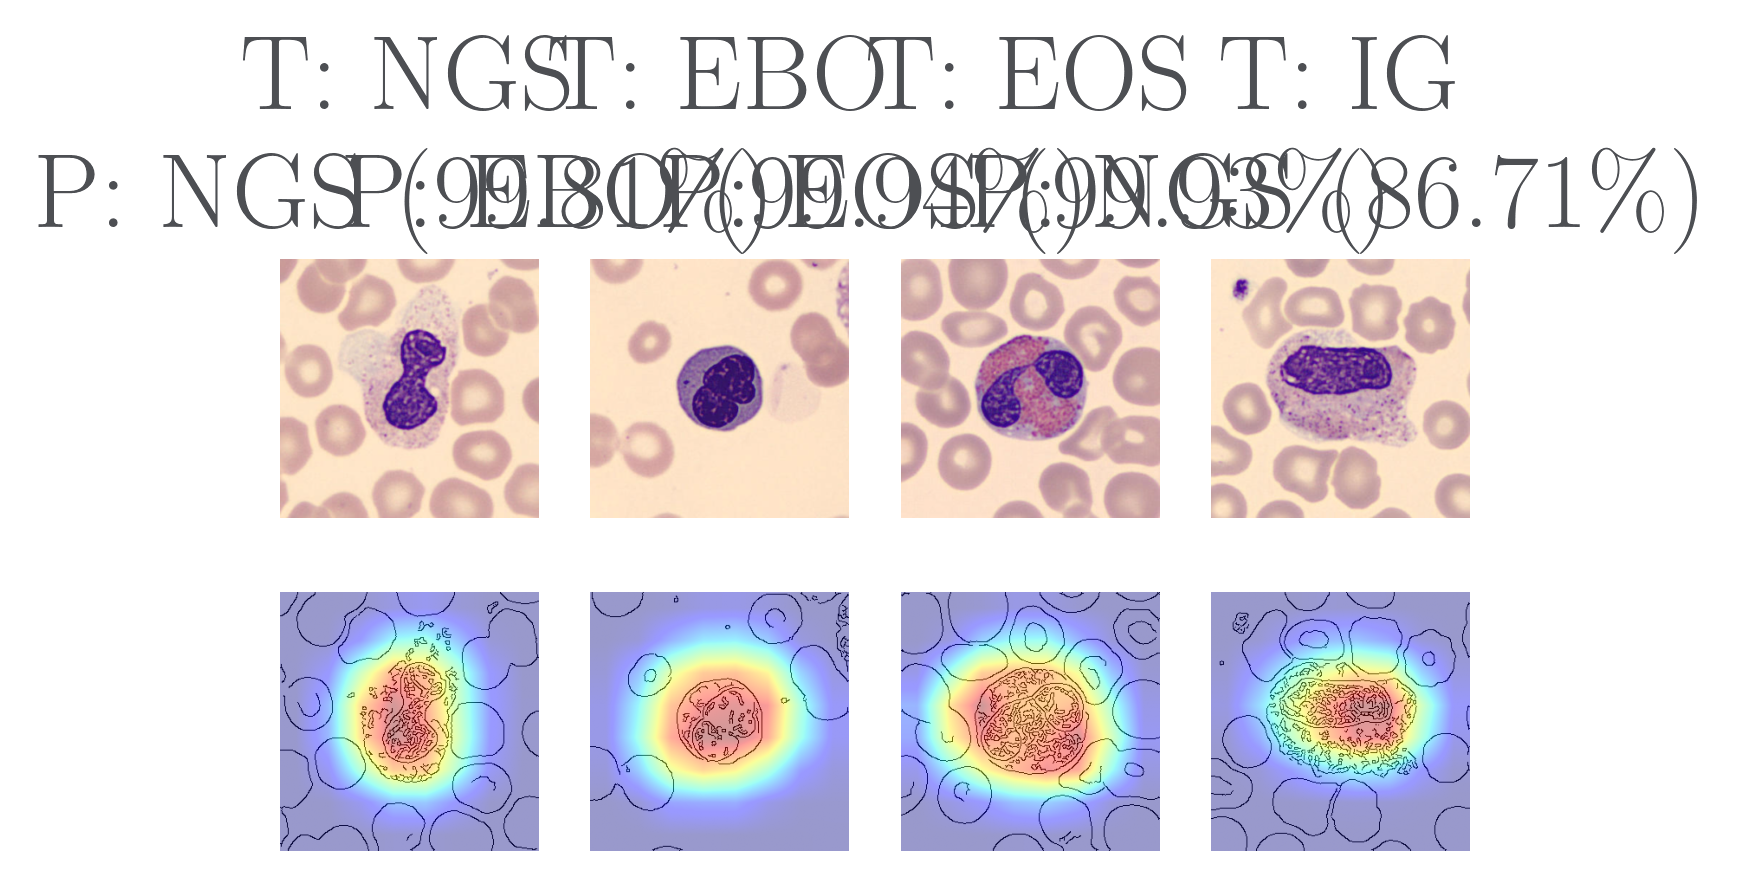

In [14]:
pplt.use_style()
fig,ax=plt.subplots(2,4,figsize=(4,3.3),gridspec_kw={'hspace':-0.4})
n=1
for batch_idx, (X_batch, y_batch) in enumerate(dataloader_test):
    for i in range(4):
        # Original image (for visualization only)
        img_disp = X_batch[i].permute(1, 2, 0).cpu().numpy()
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())
        edge = get_canny_edge(img_disp)
        # Model input (avoid double preprocess if dataloader already normalized!)
        img_tensor = preprocess(X_batch[i]).unsqueeze(0).to(device)
        
        # Forward pass
        with torch.no_grad():
            output = model(img_tensor)            
            pred_label = output.argmax(dim=1).item()
            probs = F.softmax(output, dim=1)
            pred_prob = probs[0, pred_label].item()

        true_label = y_batch[i].item()
        pred_class = pred_label
        #print(f"True: {class_names[true_label]}, Predicted: {class_names[pred_label]} ({pred_prob*100:.2f}%)")
        heatmap, pred_label = make_gradcam_heatmap(img_tensor, model, target_layer_name="Mixed_7c")  # Inception last block

        # Resize heatmap to match image
        heatmap_resized = cv2.resize(heatmap, (edge.shape[1], edge.shape[0]))
        heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]

        # Overlay
        overlay = 0.4 * heatmap_color + 0.6 * edge
        overlay = np.clip(overlay, 0, 1)

        # Plot
        ax[0,i].imshow(img_disp)
        ax[0,i].axis('off')
        ax[0,i].set_title(f"T: {class_names[true_label]} \n P: {class_names[pred_class]} ({pred_prob*100:.2f}\%)",size=20)
        ax[1,i].imshow(overlay)
        ax[1,i].axis('off')
    if batch_idx + 1 >= n:
        break

pplt.savefig('prediction.png',dpi=300)
plt.show()